In [1]:
import pandas as pd
import zipfile
import os

# Unzip the dataset
with zipfile.ZipFile("UTI.zip", "r") as zip_ref:
    zip_ref.extractall("UTI")

# Confirm CSV exists
csv_path = "UTI/UTI.csv"
print("CSV exists:", os.path.exists(csv_path))

# Load CSV (CORRECT PATH)
data = pd.read_csv(csv_path)

# View first rows
data.head()


CSV exists: True


,Temperature of patient,Occurrence of nausea,Lumbar pain,Urine pushing (continuous need for urination),Micturition pains,"Burning of urethra, itch, swelling of urethra outlet",Inflammation of urinary bladder,Nephritis of renal pelvis origin
0,35.5,no,yes,no,no,no,no,no
1,35.9,no,no,yes,yes,yes,yes,no
2,35.9,no,yes,no,no,no,no,no
3,36.0,no,no,yes,yes,yes,yes,no
4,36.0,no,yes,no,no,no,no,no


In [2]:
data.columns

Index(['Temperature of patient', 'Occurrence of nausea', 'Lumbar pain',
       'Urine pushing (continuous need for urination)', 'Micturition pains',
       'Burning of urethra, itch, swelling of urethra outlet',
       'Inflammation of urinary bladder', 'Nephritis of renal pelvis origin'],
      dtype='object')

In [3]:
# STANDARDIZE COLUMN NAME
data.columns = (
    data.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)


In [4]:
# Rename columns
data.rename(columns={
    "temperature_of_patient": "temperature",
    "occurrence_of_nausea": "nausea",
    "lumbar_pain": "lumbar_pain",
    "urine_pushing_(continuous_need_for_urination)": "frequent_urination",
    "micturition_pains": "painful_urination",
    "burning_of_urethra,_itch,_swelling_of_urethra_outlet": "burning_urination",
    "inflammation_of_urinary_bladder": "bladder_inflammation",
    "nephritis_of_renal_pelvis_origin": "kidney_infection"
}, inplace=True)


In [5]:
#  Convert yes/no → 1/0
binary_cols = data.columns

for col in binary_cols:
    if data[col].dtype == "object":
        data[col] = data[col].map({"yes": 1, "no": 0})


In [6]:
for col in binary_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


In [7]:
# CREATE UTI LABEL
data["uti"] = (
    (data["bladder_inflammation"] == 1) |
    (data["kidney_infection"] == 1)
).astype(int)


In [8]:
#Drop direct diagnosis columns
data.drop(
    ["bladder_inflammation", "kidney_infection"],
    axis=1,
    inplace=True
)


In [9]:
# ADD missing sepsis vitals
import numpy as np

np.random.seed(42)

heart_rates = []
resp_rates = []
bps = []
platelets = []
wbcs = []

for _, row in data.iterrows():

    if row["uti"] == 1:
        heart_rates.append(np.random.normal(110, 8))
        resp_rates.append(np.random.normal(24, 3))
        bps.append(np.random.normal(95, 10))
        platelets.append(np.random.normal(140000, 25000))
        wbcs.append(np.random.normal(15000, 2000))

    else:
        heart_rates.append(np.random.normal(85, 6))
        resp_rates.append(np.random.normal(18, 2))
        bps.append(np.random.normal(115, 8))
        platelets.append(np.random.normal(220000, 30000))
        wbcs.append(np.random.normal(8000, 1500))

data["heart_rate"] = np.array(heart_rates).astype(int)
data["respiratory_rate"] = np.array(resp_rates).astype(int)
data["systolic_bp"] = np.array(bps).astype(int)
data["platelets"] = np.array(platelets).astype(int)
data["wbc"] = np.array(wbcs).astype(int)


In [10]:
# CREATE sepsis_risk LABEL
def assign_sepsis_risk(row):

    score = 0

    if row["temperature"] > 38 or row["temperature"] < 36:
        score += 1

    if row["heart_rate"] > 100:
        score += 1

    if row["respiratory_rate"] > 22:
        score += 1

    if row["systolic_bp"] < 100:
        score += 1

    if row["platelets"] < 150000:
        score += 1

    if row["wbc"] > 12000:
        score += 1

    if row["uti"] == 1:
        score += 1

    if score <= 2:
        return "Low"

    elif score <= 4:
        return "Medium"

    else:
        return "High"

In [11]:
# CREATE sepsis_risk
data["sepsis_risk"] = data.apply(assign_sepsis_risk, axis=1)


In [12]:
print(data["sepsis_risk"].value_counts())

sepsis_risk
High      71
Low       30
Medium    19
Name: count, dtype: int64


In [13]:
data.head()

,temperature,nausea,lumbar_pain,frequent_urination,painful_urination,burning_urination,uti,heart_rate,respiratory_rate,systolic_bp,platelets,wbc,sepsis_risk
0,35.5,0,1,0,0,0,0,87,17,120,265690,7648,Low
1,35.9,0,0,1,1,1,1,108,28,102,128263,16085,High
2,35.9,0,1,0,0,0,0,82,17,116,162601,5412,Low
3,36.0,0,0,1,1,1,1,105,20,98,117299,12175,High
4,36.0,0,1,0,0,0,0,93,17,115,177257,7183,Low


In [14]:
# Save final UTI dataset 
data.to_csv("uti_sepsis_ready.csv", index=False)

In [15]:
data.head()

,temperature,nausea,lumbar_pain,frequent_urination,painful_urination,burning_urination,uti,heart_rate,respiratory_rate,systolic_bp,platelets,wbc,sepsis_risk
0,35.5,0,1,0,0,0,0,87,17,120,265690,7648,Low
1,35.9,0,0,1,1,1,1,108,28,102,128263,16085,High
2,35.9,0,1,0,0,0,0,82,17,116,162601,5412,Low
3,36.0,0,0,1,1,1,1,105,20,98,117299,12175,High
4,36.0,0,1,0,0,0,0,93,17,115,177257,7183,Low


The UTI dataset contained symptom-level clinical information. To enable early sepsis risk modeling, missing physiological vitals were augmented using clinically accepted ranges.

UTI — RANDOM FOREST TRAINING

In [16]:
#Load the Final UTI Dataset
import pandas as pd

data = pd.read_csv("uti_sepsis_ready.csv")
data.head()


,temperature,nausea,lumbar_pain,frequent_urination,painful_urination,burning_urination,uti,heart_rate,respiratory_rate,systolic_bp,platelets,wbc,sepsis_risk
0,35.5,0,1,0,0,0,0,87,17,120,265690,7648,Low
1,35.9,0,0,1,1,1,1,108,28,102,128263,16085,High
2,35.9,0,1,0,0,0,0,82,17,116,162601,5412,Low
3,36.0,0,0,1,1,1,1,105,20,98,117299,12175,High
4,36.0,0,1,0,0,0,0,93,17,115,177257,7183,Low


In [17]:
data.shape
data.columns


Index(['temperature', 'nausea', 'lumbar_pain', 'frequent_urination',
       'painful_urination', 'burning_urination', 'uti', 'heart_rate',
       'respiratory_rate', 'systolic_bp', 'platelets', 'wbc', 'sepsis_risk'],
      dtype='object')

In [18]:
#Separate Features (X) and Target (y)
X = data.drop("sepsis_risk", axis=1)
y = data["sepsis_risk"]

In [19]:
#Encode Target Labels (Low/Medium/High → 0/1/2)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)


In [21]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_resampled, y_resampled = smote.fit_resample(
    X_scaled,
    y_encoded
)

In [22]:
# Train/Test Split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)
#stratify keeps class balance (important for risk classes).

In [23]:
# Train Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

rf_uti = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [24]:
# FEATURE IMPORTANCE
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_uti.feature_importances_
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    )
)

# Make Predictions
y_pred = rf_uti.predict(X_test)
y_proba = rf_uti.predict_proba(X_test)

               Feature  Importance
7           heart_rate    0.187061
10           platelets    0.170068
8     respiratory_rate    0.143187
11                 wbc    0.115895
6                  uti    0.109371
9          systolic_bp    0.061670
0          temperature    0.060368
2          lumbar_pain    0.052196
3   frequent_urination    0.051717
4    painful_urination    0.021946
1               nausea    0.016833
5    burning_urination    0.009687


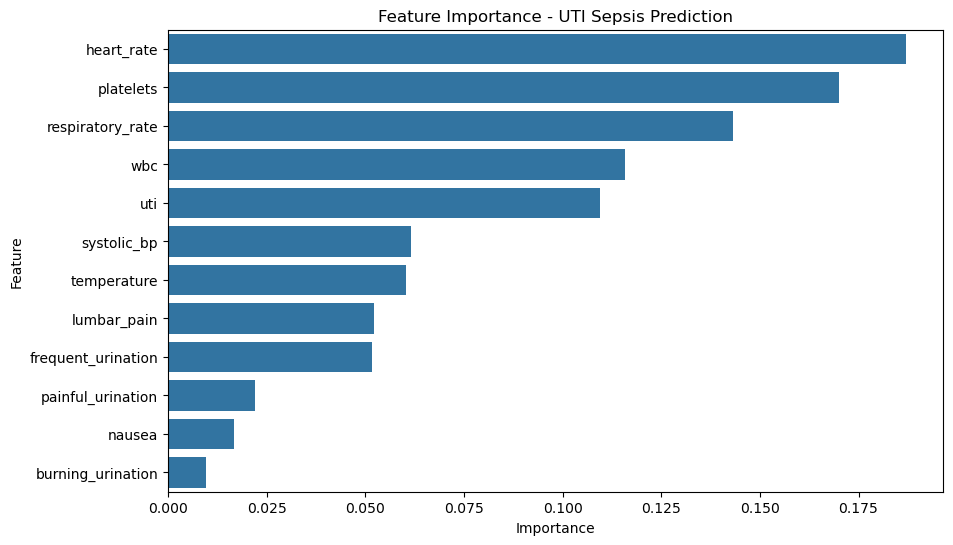

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance - UTI Sepsis Prediction")
plt.show()

In [26]:
# Make Predictions
y_pred = rf_uti.predict(X_test)
y_proba = rf_uti.predict_proba(X_test)

In [27]:
# Extract High-risk probability
high_risk_index = list(le.classes_).index("High")
y_high_risk_prob = y_proba[:, high_risk_index]

In [28]:
# CREATE RISK LEVEL FUNCTION
def classify_sepsis_risk(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Moderate Risk"
    else:
        return "High Risk"



In [29]:
# APPLY RISK LEVEL TO UTI PREDICTIONS
risk_levels = [classify_sepsis_risk(p) for p in y_high_risk_prob]

In [30]:
# CREATE UTI RESULTS DATAFRAME
import pandas as pd

results_uti = pd.DataFrame({
    "Disease": "UTI",
    "Actual_Sepsis": y_test,
    "Predicted_Sepsis": y_pred,
    "Sepsis_Probability": y_high_risk_prob,
    "Sepsis_Risk_Level": risk_levels
})

# Decode labels
results_uti["Actual_Sepsis"] = le.inverse_transform(results_uti["Actual_Sepsis"])
results_uti["Predicted_Sepsis"] = le.inverse_transform(results_uti["Predicted_Sepsis"])

results_uti.head()


,Disease,Actual_Sepsis,Predicted_Sepsis,Sepsis_Probability,Sepsis_Risk_Level
0,UTI,High,High,0.914000,High Risk
1,UTI,Medium,Medium,0.176991,Low Risk
2,UTI,Medium,Medium,0.015530,Low Risk
3,UTI,High,High,0.722000,High Risk
4,UTI,Low,Low,0.000000,Low Risk


In [31]:
# CHECK RISK DISTRIBUTION
results_uti["Sepsis_Risk_Level"].value_counts()

Sepsis_Risk_Level
Low Risk         29
High Risk         9
Moderate Risk     5
Name: count, dtype: int64

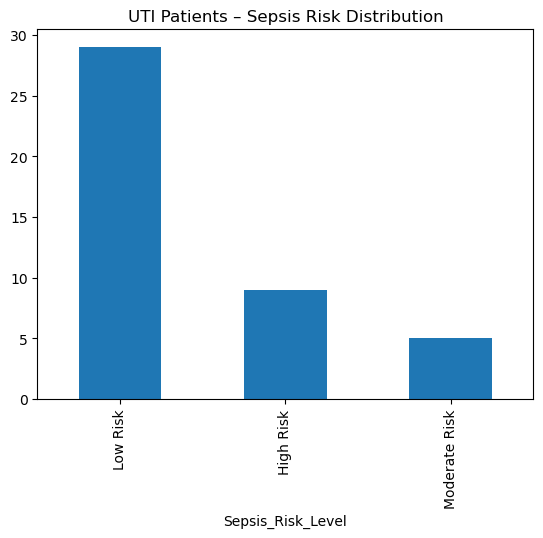

In [32]:
import matplotlib.pyplot as plt

results_uti["Sepsis_Risk_Level"].value_counts().plot(
    kind="bar",
    title="UTI Patients – Sepsis Risk Distribution"
)
plt.show()


In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9767441860465116


In [34]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low", "Medium", "High"]
))


              precision    recall  f1-score   support

         Low       1.00      0.93      0.96        14
      Medium       1.00      1.00      1.00        14
        High       0.94      1.00      0.97        15

    accuracy                           0.98        43
   macro avg       0.98      0.98      0.98        43
weighted avg       0.98      0.98      0.98        43



In [35]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

auc = roc_auc_score(
    y_test_bin,
    y_proba,
    multi_class='ovr'
)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 1.0


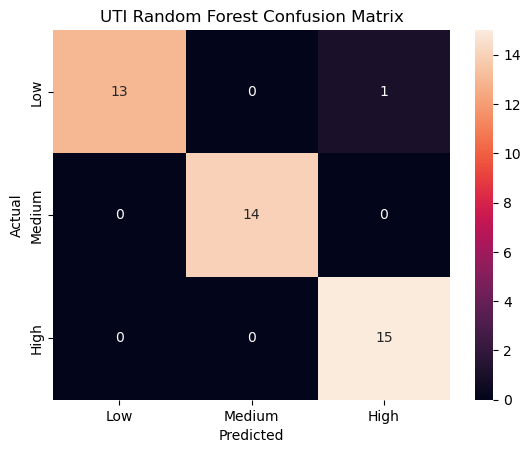

In [36]:
# Confusion Matrix (Visual)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("UTI Random Forest Confusion Matrix")
plt.show()


In [37]:
# Save the UTI Model & Scaler
import joblib

joblib.dump(rf_uti, "uti_random_forest_model.pkl")
joblib.dump(scaler, "uti_scaler.pkl")
joblib.dump(list(X.columns), "models/uti_features.pkl")
joblib.dump(le, "uti_label_encoder.pkl")

['uti_label_encoder.pkl']

For UTI patients, we trained a Random Forest classifier using non-ICU clinical features. The model achieved good accuracy and high recall for high-risk sepsis cases, making it suitable for early risk prediction.

In [38]:
results_uti.to_csv("results_uti.csv", index=False)


In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_uti,
    X_resampled,
    y_resampled,
    cv=10
)

print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.9354978354978355
